## Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch import optim
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.datasets import ImageFolder
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Dataloaders

In [3]:
transform = T.Compose([T.Resize((224,224)),
                       T.ToTensor()])

dataset = ImageFolder(root='dataset/train', transform=transform)
trn_dataset, val_dataset = random_split(dataset, [0.8, 0.2])

train_loader = DataLoader(trn_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=True)

## ResNet50 Pretrained Model for Intermediate Layer Feature Extraction

In [4]:
class ResnetFeatures(nn.Module):
    def __init__(self):
        """This class extracts the feature maps from a pretrained Resnet50 model"""
        super(ResnetFeatures, self).__init__()
        self.model = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False        

        # Hook to extract feature maps
        def hook(module, input, output) -> None:
            """This hook saves the extracted feature map on self.features"""
            self.features.append(output)

        self.model.layer2[-1].register_forward_hook(hook)            
        self.model.layer3[-1].register_forward_hook(hook) 

    def forward(self, input):

        self.features = []
        with torch.no_grad():
            _ = self.model(input)

        self.avg = torch.nn.AvgPool2d(3, stride=1)
        fmap_size = self.features[0].shape[-2]         # Feature map sizes h, w
        self.resize = torch.nn.AdaptiveAvgPool2d(fmap_size)

        resized_maps = [self.resize(self.avg(fmap)) for fmap in self.features]
        patch = torch.cat(resized_maps, 1)            # Merge the resized feature maps

        return patch

## AutoEncoder Model with 1x1 Convolution for Anomaly Detection

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, in_channels=1000, latent_dim=50, is_bn=True):
        super(AutoEncoder, self).__init__()

        layers = []
        layers += [nn.Conv2d(in_channels, (in_channels + 2 * latent_dim) // 2, kernel_size=1, stride=1, padding=0)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features=(in_channels + 2 * latent_dim) // 2)]
        layers += [nn.ReLU()]
        layers += [nn.Conv2d((in_channels + 2 * latent_dim) // 2, 2 * latent_dim, kernel_size=1, stride=1, padding=0)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features=2 * latent_dim)]
        layers += [nn.ReLU()]
        layers += [nn.Conv2d(2 * latent_dim, latent_dim, kernel_size=1, stride=1, padding=0)]

        self.encoder = nn.Sequential(*layers)

        
        layers = []
        layers += [nn.Conv2d(latent_dim, 2 * latent_dim, kernel_size=1, stride=1, padding=0)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features=2 * latent_dim)]
        layers += [nn.ReLU()]
        layers += [nn.Conv2d(2 * latent_dim, (in_channels + 2 * latent_dim) // 2, kernel_size=1, stride=1, padding=0)]
        if is_bn:
            layers += [nn.BatchNorm2d(num_features=(in_channels + 2 * latent_dim) // 2)]
        layers += [nn.ReLU()]
        layers += [nn.Conv2d((in_channels + 2 * latent_dim) // 2, in_channels, kernel_size=1, stride=1, padding=0)]
        
        self.decoder = nn.Sequential(*layers)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## Initialize Models, Loss Function and Optimizer

In [6]:
model = AutoEncoder(in_channels=1536, latent_dim=100).to(device)
feat_extractor = ResnetFeatures().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

## Train and Validate the Model

In [7]:
Train_Loss = []
Validation_Loss = []
best_val_loss = np.inf
patience = 5
counter = 0

num_epochs = 50
for epoch in tqdm(range(num_epochs)):
    model.train()
    for data,_ in train_loader:
        with torch.no_grad():
            features = feat_extractor(data.to(device))
        output = model(features)        
        loss = criterion(output, features)        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    Train_Loss.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss_sum = 0.0
        num_batches = 0
        for data, _ in val_loader:
            features = feat_extractor(data.to(device))
            output = model(features)
            val_loss = criterion(output, features)
            val_loss_sum += val_loss.item()
            num_batches += 1
        val_loss_avg = val_loss_sum / num_batches

        scheduler.step(val_loss_avg)
        Validation_Loss.append(val_loss_avg)
    
    if epoch % 5 == 0:
        print('Epoch [{}/{}], Loss: {:.4f}, Validation Loss: {:.4f}'.format(epoch + 1, num_epochs, loss.item(), val_loss_avg))
    
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        counter = 0
    else:
        counter += 1        
        if counter >= patience:
            print('Early Stopping!')
            break       


  2%|▏         | 1/50 [00:01<01:32,  1.88s/it]

Epoch [1/50], Loss: 0.1944, Validation Loss: 0.5110


 12%|█▏        | 6/50 [00:04<00:31,  1.40it/s]

Epoch [6/50], Loss: 0.0441, Validation Loss: 0.0489


 22%|██▏       | 11/50 [00:07<00:22,  1.73it/s]

...

 82%|████████▏ | 41/50 [00:25<00:05,  1.54it/s]

Epoch [41/50], Loss: 0.0223, Validation Loss: 0.0283


 92%|█████████▏| 46/50 [00:28<00:02,  1.62it/s]

Epoch [46/50], Loss: 0.0235, Validation Loss: 0.0276


100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


## Visualize the Learning Curves

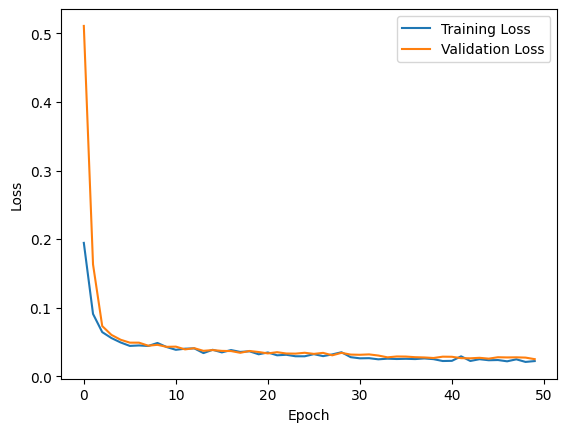

In [8]:
plt.plot(Train_Loss, label='Training Loss')
plt.plot(Validation_Loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## Save the Trained Model

In [9]:
torch.save(model.state_dict(), 'AE_ResNet50.pth')

## Load the Model

In [10]:
ckpoints = torch.load('AE_ResNet50.pth')
model.load_state_dict(ckpoints)

model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1536, 868, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(868, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(868, 200, kernel_size=(1, 1), stride=(1, 1))
    (4): BatchNorm2d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(200, 100, kernel_size=(1, 1), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): Conv2d(100, 200, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(200, 868, kernel_size=(1, 1), stride=(1, 1))
    (4): BatchNorm2d(868, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(868, 1536, kernel_size=(1, 1), stride=(1, 1))
  )
)

## Visualize theAbnormal Image Result

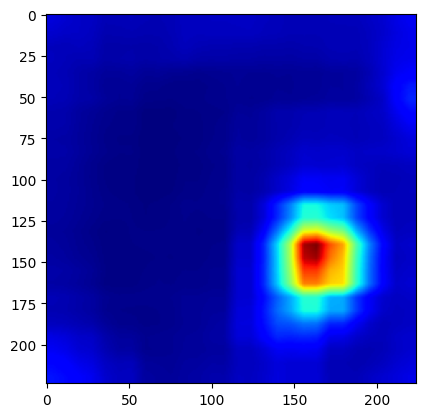

In [11]:
image = Image.open(r'dataset/test/bad/20221017_T28_C3_S3.png')
image = transform(image).unsqueeze(0)

with torch.no_grad():
    features = feat_extractor(image.to(device))
    recon = model(features)

recon_error =  ((features-recon)**2).mean(axis=(1)).unsqueeze(0)

segm_map = torch.nn.functional.interpolate(     # Upscale by bi-linaer interpolation to match the original input resolution
                recon_error,
                size=(224, 224),
                mode='bilinear'
            )

plt.imshow(segm_map.squeeze().cpu().numpy(), cmap='jet')
plt.show()

## Decision Function for Anomaly Threshold

In [13]:
def decision_function(segm_map):  

    mean_top_10_values = []

    for map in segm_map:        
        flattened_tensor = map.reshape(-1)
        
        sorted_tensor, _ = torch.sort(flattened_tensor,descending=True)
        
        mean_top_10_value = sorted_tensor[:10].mean()

        mean_top_10_values.append(mean_top_10_value)

    return torch.stack(mean_top_10_values)

## Calculate Reconstruction Error for Anomaly Threshold

In [14]:
model.eval()

RECON_ERROR=[]
for data,_ in train_loader:
    
    with torch.no_grad():
        features = feat_extractor(data.to(device)).squeeze()        
        recon = model(features)
    
    segm_map =  ((features-recon)**2).mean(axis=(1))[:,3:-3,3:-3]
    anomaly_score = decision_function(segm_map)    
    
    RECON_ERROR.append(anomaly_score)
    
RECON_ERROR = torch.cat(RECON_ERROR).cpu().numpy()

## Calculating Best Threshold for Anomaly Detection

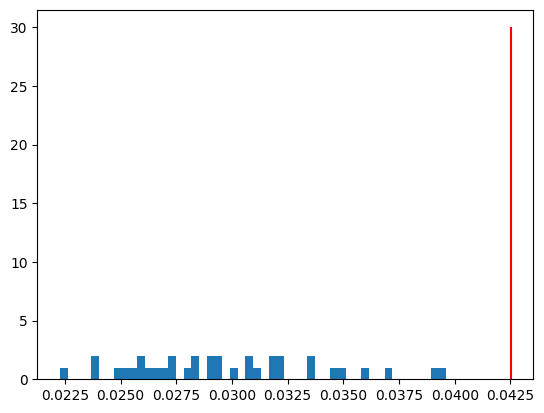

In [15]:
best_threshold = np.mean(RECON_ERROR) + 3 * np.std(RECON_ERROR)

heat_map_max, heat_map_min = np.max(RECON_ERROR), np.min(RECON_ERROR)

plt.hist(RECON_ERROR,bins=50)
plt.vlines(x=best_threshold,ymin=0,ymax=30,color='r')
plt.show()

## Predicting with Test Images

In [16]:

y_true=[]
y_pred=[]
y_score=[]

model.eval()
feat_extractor.eval()

test_path = Path('dataset/test')

for path in test_path.glob('*/*.*'):    
    fault_type = path.parts[-2]    
    test_image = transform(Image.open(path)).to(device).unsqueeze(0)
    
    with torch.no_grad():
        features = feat_extractor(test_image)        
        recon = model(features)
    
    segm_map = ((features - recon)**2).mean(axis=(1))[:,3:-3,3:-3]
    y_score_image = decision_function(segm_map=segm_map)
    
    
    y_pred_image = 1*(y_score_image >= best_threshold)
    
    y_true_image = 0 if fault_type == 'good' else 1
    
    y_true.append(y_true_image)
    y_pred.append(y_pred_image.cpu().numpy())
    y_score.append(y_score_image.cpu().numpy())
    
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

## Visualize Predicted Anomaly Scores with Best Threshold

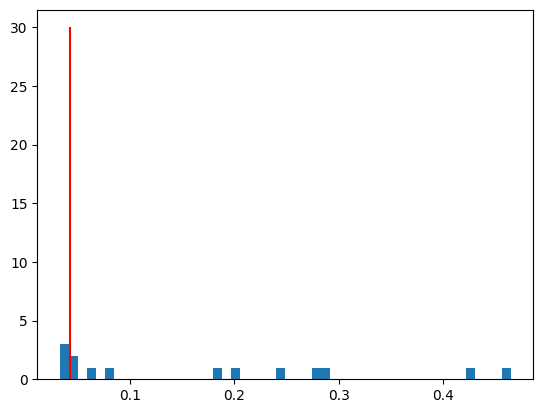

In [17]:
plt.hist(y_score,bins=50)
plt.vlines(x=best_threshold,ymin=0,ymax=30,color='r')
plt.show()

## Visualize the ROC Curve and Confusion Matrix

AUC-ROC Score: 1.0


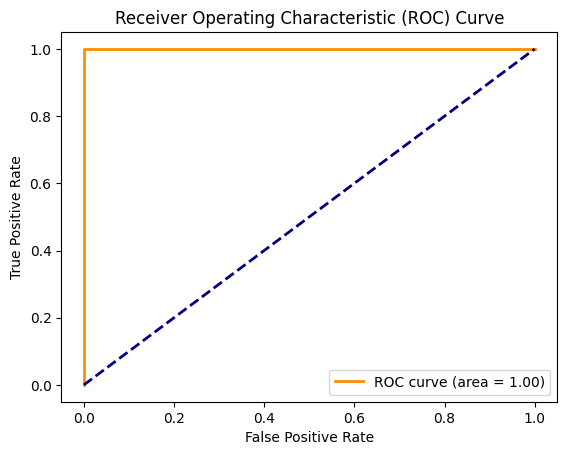

best_threshold = 0.06594765931367874


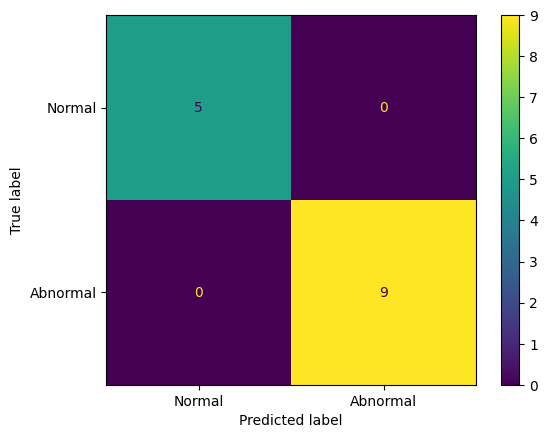

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score
import seaborn as sns

auc_roc_score = roc_auc_score(y_true, y_score)
print("AUC-ROC Score:", auc_roc_score)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_roc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



f1_scores = [f1_score(y_true, y_score >= threshold) for threshold in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)] # finding best threshold based on f1 scores

print(f'best_threshold = {best_threshold}')

cm = confusion_matrix(y_true, (y_score >= best_threshold).astype(int), labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Normal','Abnormal'])
disp.plot()
plt.show()

## Visualize the Abnormal Part in Test Abnormal Images

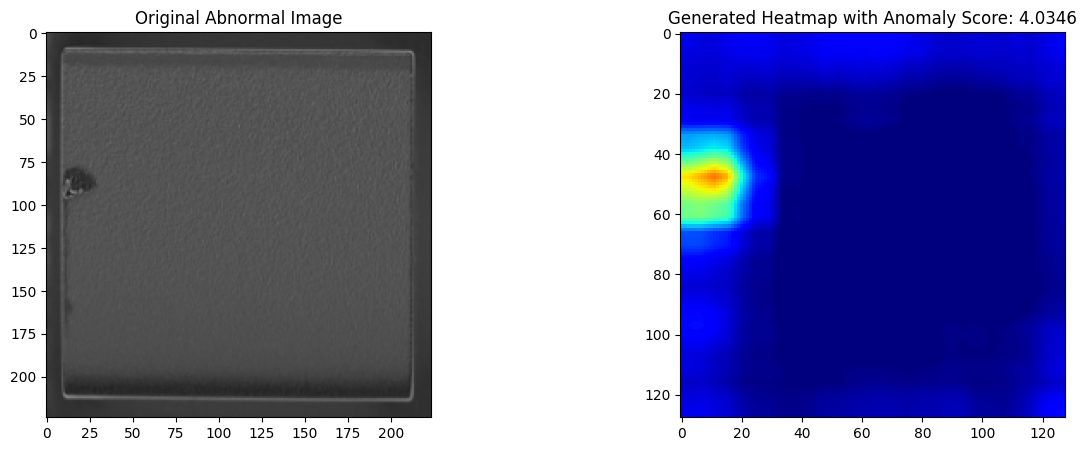

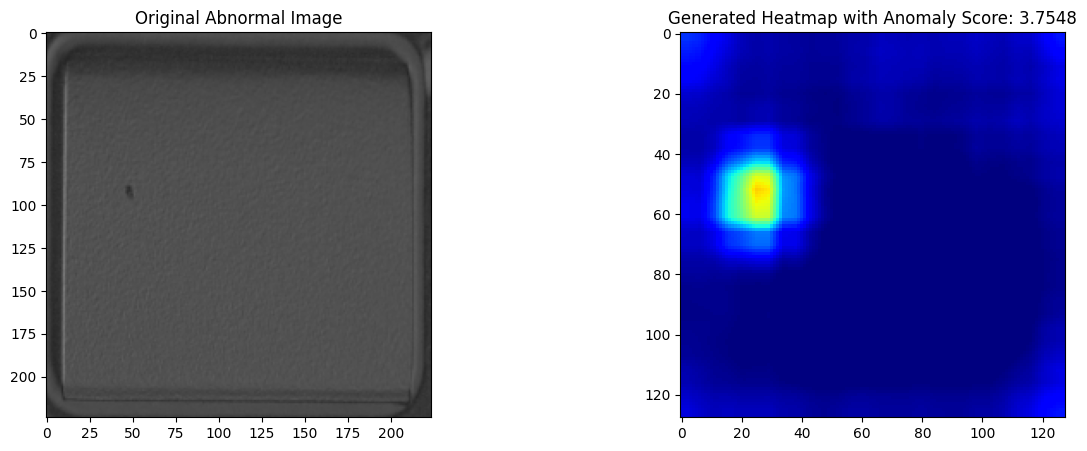

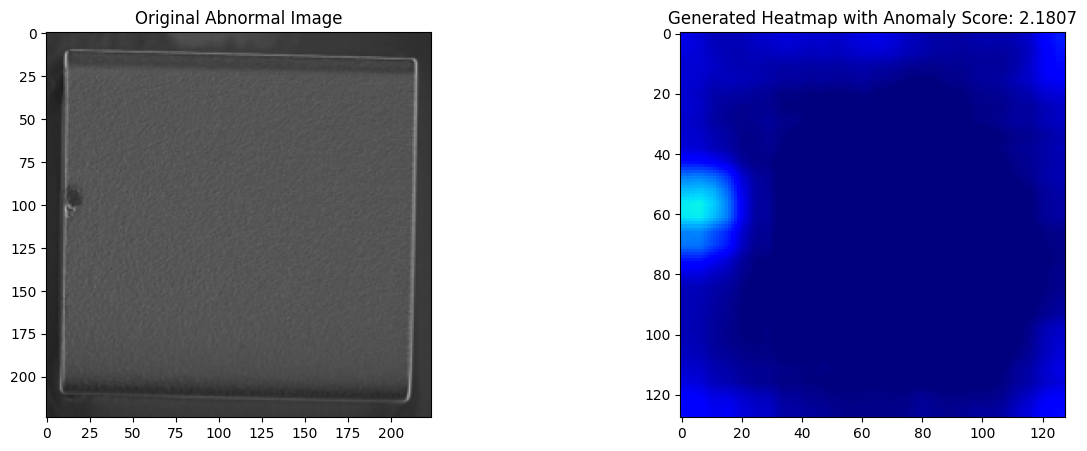

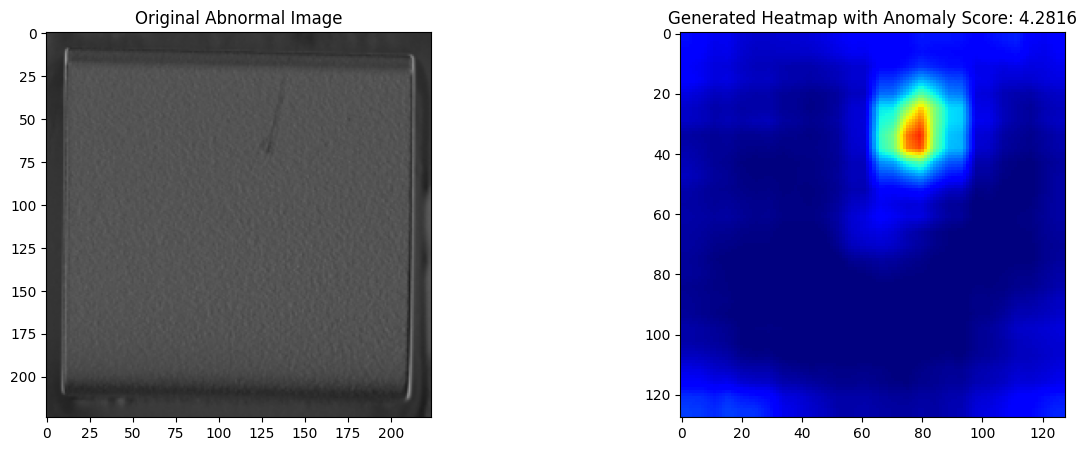

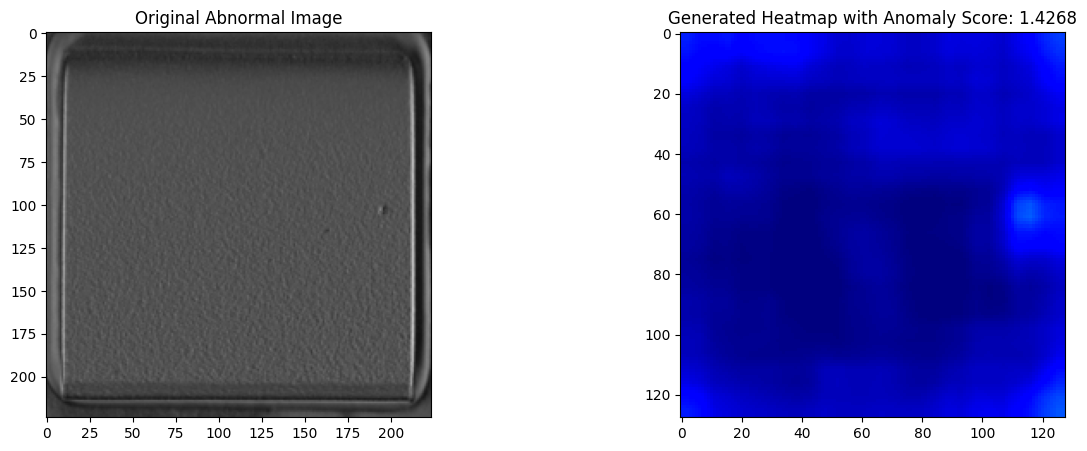

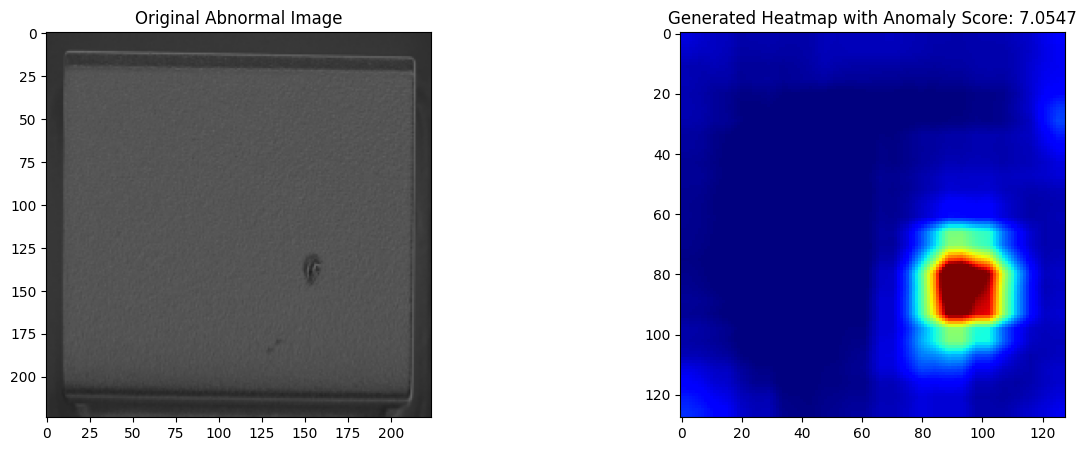

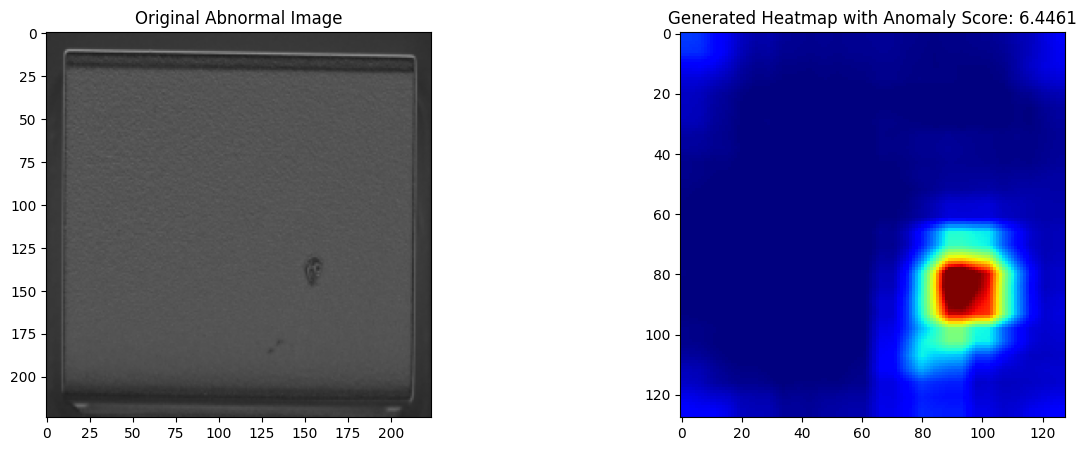

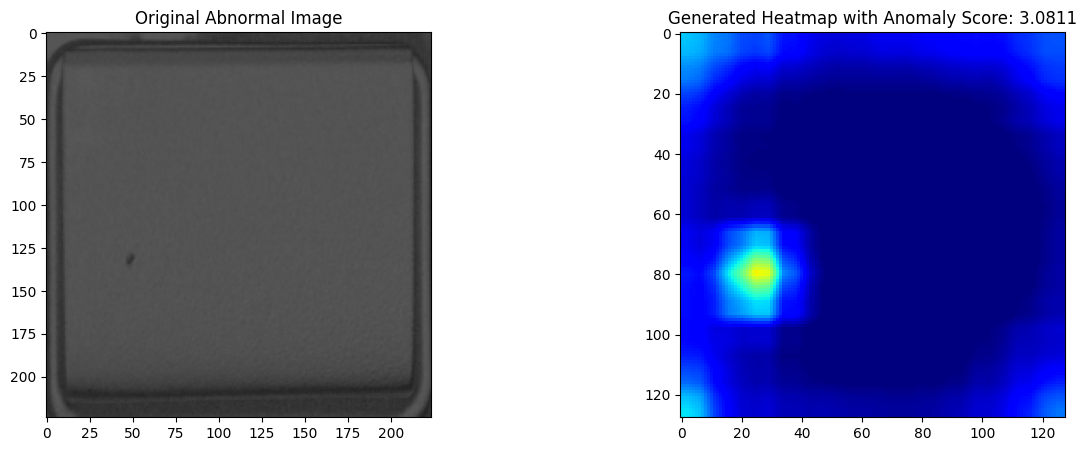

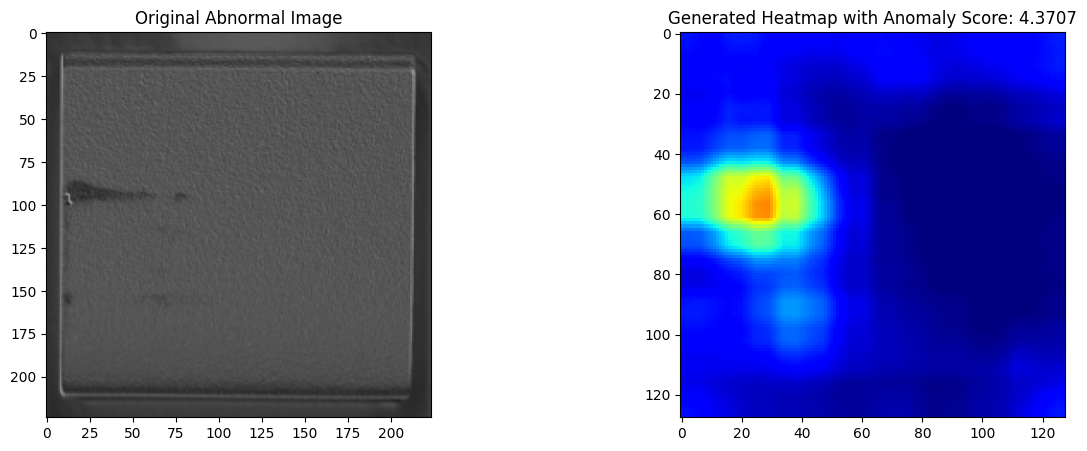

In [20]:
import cv2

model.eval()
feat_extractor.eval()

test_path = Path('dataset/test')

for path in test_path.glob('*/*.*'):
    fault_type = path.parts[-2]
    test_image = transform(Image.open(path)).to(device).unsqueeze(0)
    
    with torch.no_grad():
        features = feat_extractor(test_image)        
        recon = model(features)
    
    segm_map = ((features - recon)**2).mean(axis=(1))
    y_score_image = decision_function(segm_map=segm_map)    
    
    y_pred_image = 1*(y_score_image >= best_threshold)
    class_label = ['Normal','Abnormal']

    if fault_type in ['bad']:

        plt.figure(figsize=(15,5))

        plt.subplot(1,2,1)
        plt.imshow(test_image.squeeze().permute(1,2,0).cpu().numpy())        
        plt.title('Original Abnormal Image')

        plt.subplot(1,2,2)
        heat_map = segm_map.squeeze().cpu().numpy()
        heat_map = heat_map
        heat_map = cv2.resize(heat_map, (128,128))
        plt.imshow(heat_map, cmap='jet', vmin=heat_map_min, vmax=heat_map_max*10)
        plt.title(f'Generated Heatmap with Anomaly Score: {y_score_image[0].cpu().numpy() / best_threshold:0.4f}')

                
        plt.show()